### Dataset Information
- Name: BriscMat-Brain-Tumour-MRI-Dataset-2026
- Source: Kaggle obtained via https://www.kaggle.com/datasets/vivanrv/briscmat-brain-tumour-mri-dataset-2026

Imported using kagglehub library


### Dataset Description
This dataset contains 2D brain MRI slices for:
- Tumor classification
- Tumor segmentation
- Multi-view analysis

Each sample is stored as an individual `.mat` file.

Tumors are categorized as No Tumor (0), Meningioma (1), Glioma (2), and Pituitary Tumor (3)

MRI Views Code View: Axial (1), Coronal (2), Sagittal (3)


### Dataset Statistics

Dataset splitted into 1000 test samples and 5000 train samples

Test samples distribution:
- Category Distribution: Glioma 254, Meningioma 306, No Tumor 140, Pituitary 300.
- View Distribution: Axial 398, Coronal 305, Sagittal 297.

Train samples distribution:
- Category Distribution: Glioma 1147, Meningioma 1329, No Tumor 1067, Pituitary 1457.
- View Distribution: Axial 1595, Coronal 1676, Sagittal 1729.


### File Content (.mat keys)
Each `.mat` file contains the following keys:
- cjdata.label: Tumor class label (0 → No Tumor, 1 → Meningioma, 2 → Glioma, 3 → Pituitary)
- cjdata.image: Grayscale MRI image (2D NumPy array, typically 0–255)
- cjdata.tumorMask:Binary segmentation mask (1 → Tumor, 0 → Background)
- cjdata.view: View identifier (1 → Axial, 2 → Coronal, 3 → Sagittal)

### Key Characteristics
- Multi-class tumor dataset (4 classes)
- Multi-view MRI images
- Supports:
  - Classification tasks
  - Segmentation tasks
  - Multi-task deep learning
  - View-aware modeling

#### Data Loading via Kaggle Hub

In [12]:
import kagglehub

path = kagglehub.dataset_download("vivanrv/briscmat-brain-tumour-mri-dataset-2026")

print("Path to dataset files:", path)


Path to dataset files: C:\Users\steve\.cache\kagglehub\datasets\vivanrv\briscmat-brain-tumour-mri-dataset-2026\versions\1


#### Section 0: Dataset Preparation & Extraction and MAT File Loader

In [13]:
import os
import logging
import numpy as np
from scipy.io import loadmat

logger = logging.getLogger(__name__)

LABEL_MAP = {
    0: "No Tumor",
    1: "Meningioma",
    2: "Glioma",
    3: "Pituitary"
}

VIEW_MAP = {
    1: "Axial",
    2: "Coronal",
    3: "Sagittal"
}

def load_mat_file(path):
    """
    Safely load a .mat file using scipy.io.
    Returns the matlab dictionary or None if it fails.
    """
    try:
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return None
            
        mat_dict = loadmat(path)
        return mat_dict
        
    except Exception as e:
        logger.error(f"Failed to read corrupt/invalid .mat file {path}: {e}")
        return None

def extract_cjdata(mat_dict, path="Unknown_Path"):
    try:
        if 'cjdata.image' in mat_dict:
            image = np.array(mat_dict['cjdata.image']).astype(np.float32)
            mask_data = mat_dict.get('cjdata.tumorMask')
            if mask_data is not None:
                mask = np.array(mask_data).astype(np.uint8)
            else:
                mask = np.zeros_like(image, dtype=np.uint8)
            
            label_data = mat_dict.get('cjdata.label')
            label = int(np.array(label_data).item()) if label_data is not None else 0
            
            view_data = mat_dict.get('cjdata.view')
            view = int(np.array(view_data).item()) if view_data is not None and np.array(view_data).size > 0 else 1

        elif 'cjdata' in mat_dict:
            cjdata = mat_dict['cjdata']
            if isinstance(cjdata, np.ndarray) and cjdata.dtype.names is not None:
                struct = cjdata[0,0] if cjdata.ndim == 2 else cjdata[0]
                image = np.array(struct['image']).astype(np.float32)
                if 'tumorMask' in struct.dtype.names:
                    mask = np.array(struct['tumorMask']).astype(np.uint8)
                else:
                    mask = np.zeros_like(image, dtype=np.uint8)
                    
                label = int(np.array(struct['label']).item())
                
                if 'view' in struct.dtype.names and struct['view'].size > 0:
                    view = int(np.array(struct['view']).item())
                else:
                    view = 1
            else:
                return None
        else:
            return None
            
        if image.ndim != 2:
            return None
        if mask.ndim != 2:
            mask = np.zeros_like(image, dtype=np.uint8)
            
        return {
            'image': image,
            'mask': mask,
            'label': label,
            'view': view
        }
    except Exception as e:
        logger.error(f"Error extracting data from {path}: {e}")
        return None

def summarize_distributions(metadata_list):
    """
    Takes a list of dictionaries (from JSON metadata) and calculates statistics.
    """
    stats = {
        'total': len(metadata_list),
        'labels': {val: 0 for val in LABEL_MAP.keys()},
        'views': {val: 0 for val in VIEW_MAP.keys()}
    }
    
    for item in metadata_list:
        l = item.get('label')
        v = item.get('view')
        
        if l in stats['labels']:
            stats['labels'][l] += 1
        if v in stats['views']:
            stats['views'][v] += 1
            
    return stats


#### Section 1: Exploratory Data Analysis (EDA)

Starting EDA on maximum 500 random samples...
Extracting data for EDA...
Successfully extracted 500 samples.

[1.1] Generating Spatial Overlays (showing 4 random samples)
Overlay plot saved to eda_outputs/overlay.png


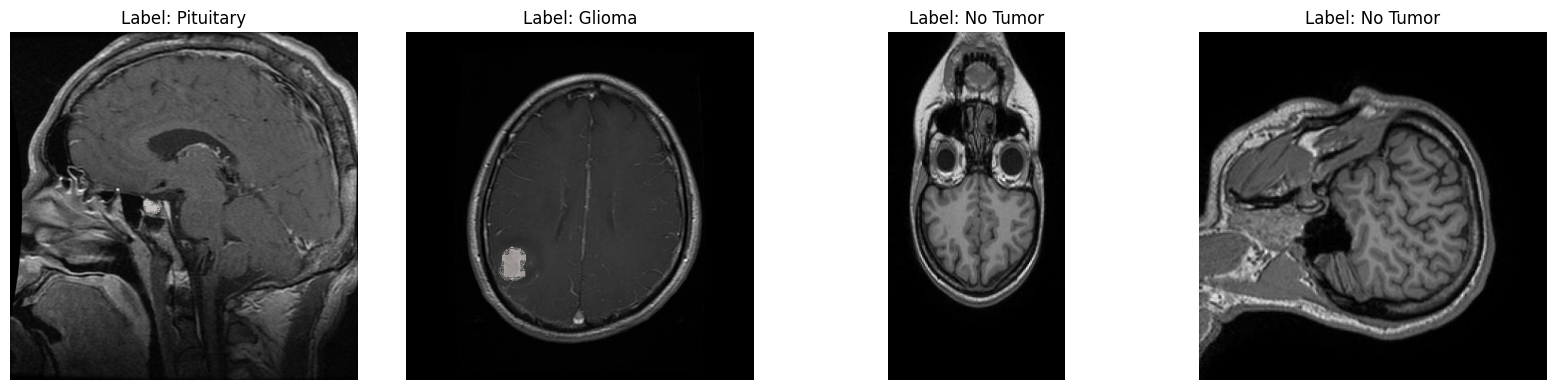


[1.2] Generating Pixel Intensity Distribution
Intensity plot saved to eda_outputs/intensity_hist.png


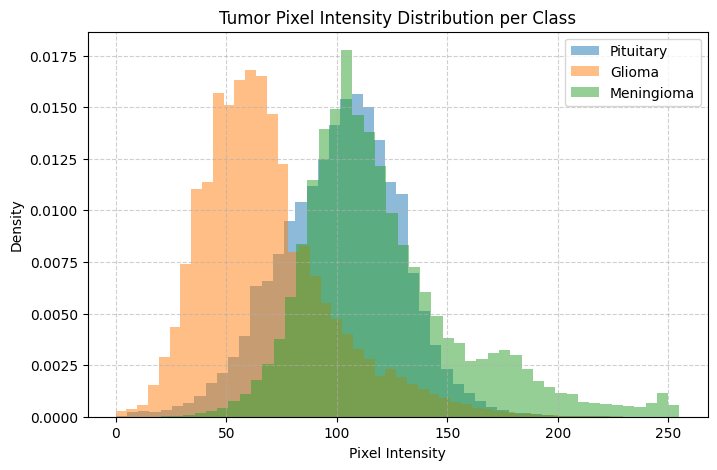


[1.3] Generating Geometric Profiles
Geometry plot saved to eda_outputs/geometry_boxplot.png


C:\Users\steve\AppData\Local\Temp\ipykernel_11556\2953632505.py:84: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, patch_artist=True)


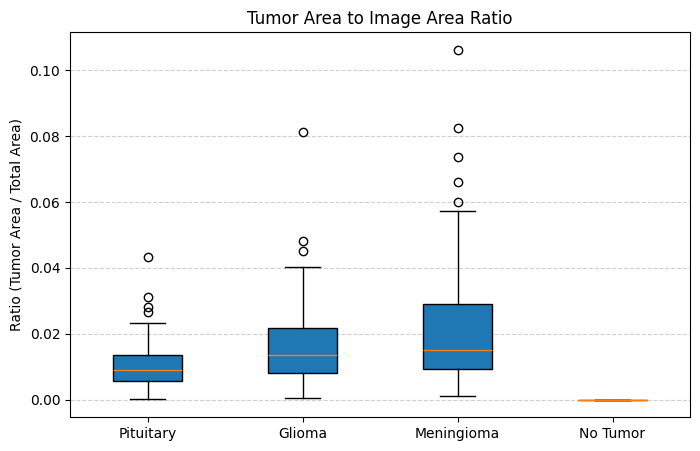


[1.4] Tabulating View vs Label
--------------------------------------------------
Cross-Tabulation: Label vs View
Label / View         | Axial | Coronal | Sagittal
--------------------------------------------------
No Tumor             | 35    | 29      | 29      
Meningioma           | 43    | 57      | 49      
Glioma               | 44    | 43      | 32      
Pituitary            | 30    | 60      | 49      
--------------------------------------------------

EDA Completed! Plots saved in 'eda_outputs/' directory.


In [15]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_spatial_overlay(samples, save_path=None):
    """
    Sub 1.1: Spatial Overlay.
    Plots image with transparent mask on top to verify mask alignment.
    """
    n = len(samples)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
        
    for ax, data in zip(axes, samples):
        img = data['image']
        mask = data['mask']
        label_name = LABEL_MAP.get(data['label'], f"Unknown({data['label']})")
        
        ax.imshow(img, cmap='gray')
        masked_mask = np.ma.masked_where(mask == 0, mask)
        ax.imshow(masked_mask, cmap='Reds', alpha=0.5)
        
        ax.set_title(f"Label: {label_name}")
        ax.axis('off')
        
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
        print(f"Overlay plot saved to {save_path}")
    plt.show()

def plot_pixel_intensity_distribution(samples, save_path=None):
    """
    Sub 1.2: Analisis Intensitas Piksel
    Plot histogram of intensities for pixels inside the tumor (mask == 1) grouped by label.
    """
    intensities = defaultdict(list)
    
    for data in samples:
        if np.any(data['mask'] == 1):
            tumor_pixels = data['image'][data['mask'] == 1].flatten()
            label_name = LABEL_MAP.get(data['label'], str(data['label']))
            intensities[label_name].extend(tumor_pixels)
            
    plt.figure(figsize=(8, 5))
    for label_name, pixel_vals in intensities.items():
        if len(pixel_vals) > 0:
            plt.hist(pixel_vals, bins=50, alpha=0.5, label=label_name, density=True)
            
    plt.title("Tumor Pixel Intensity Distribution per Class")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if save_path:
        plt.savefig(save_path)
        print(f"Intensity plot saved to {save_path}")
    plt.show()

def plot_geometry_profile(samples, save_path=None):
    """
    Sub 1.3: Profil Geometri
    Calculates Ratio = Area Tumor / Area Image. Placed in a boxplot per class to find outliers.
    """
    ratios = defaultdict(list)
    
    for data in samples:
        img_area = data['image'].shape[0] * data['image'].shape[1]
        tumor_area = np.sum(data['mask'] == 1)
        ratio = tumor_area / img_area
        
        label_name = LABEL_MAP.get(data['label'], str(data['label']))
        ratios[label_name].append(ratio)
        
    labels = list(ratios.keys())
    data_to_plot = [ratios[lbl] for lbl in labels]
    
    plt.figure(figsize=(8, 5))
    plt.boxplot(data_to_plot, labels=labels, patch_artist=True)
    plt.title("Tumor Area to Image Area Ratio")
    plt.ylabel("Ratio (Tumor Area / Total Area)")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    if save_path:
        plt.savefig(save_path)
        print(f"Geometry plot saved to {save_path}")
    plt.show()

def analyze_label_vs_view(samples):
    """
    Sub 1.4: Tabulasi Silang Label vs View.
    Calculates cross-tabulation and prints it neatly.
    """
    cross_tab = np.zeros((len(LABEL_MAP), len(VIEW_MAP)+1), dtype=int)
    
    for data in samples:
        lbl = data['label']
        view = data['view']
        
        if lbl in LABEL_MAP and view in VIEW_MAP:
            cross_tab[lbl][view-1] += 1
            
    print("-" * 50)
    print("Cross-Tabulation: Label vs View")
    print(f"{'Label / View':<20} | {' | '.join(list(VIEW_MAP.values()))}")
    print("-" * 50)
    
    for lbl_id, lbl_name in LABEL_MAP.items():
        counts = cross_tab[lbl_id][:3]
        counts_str = [f"{c:<{len(VIEW_MAP[v+1])}}" for v, c in enumerate(counts)]
        print(f"{lbl_name:<20} | {' | '.join(counts_str)}")
        
    print("-" * 50)

def run_eda(dataset_path, num_samples=1000, seed=42):
    """
    Orchestrator for EDA. Reads `num_samples` random .mat files and runs all phase 0 analysis.
    """
    print(f"Starting EDA on maximum {num_samples} random samples...")
    mat_files = glob.glob(os.path.join(dataset_path, '**', '*.mat'), recursive=True)
    
    if not mat_files:
        print(f"No .mat files found in {dataset_path}!")
        return
        
    random.seed(seed)
    sampled_files = random.sample(mat_files, min(num_samples, len(mat_files)))
    
    extracted_data = []
    
    print("Extracting data for EDA...")
    for file in sampled_files:
        mat_dict = load_mat_file(file)
        if mat_dict:
            data = extract_cjdata(mat_dict, file)
            if data is not None:
                extracted_data.append(data)
                
    print(f"Successfully extracted {len(extracted_data)} samples.")
    
    if len(extracted_data) == 0:
        return
        
    os.makedirs('eda_outputs', exist_ok=True)
    
    print("\n[1.1] Generating Spatial Overlays (showing 4 random samples)")
    overlay_samples = random.sample(extracted_data, min(4, len(extracted_data)))
    plot_spatial_overlay(overlay_samples, save_path='eda_outputs/overlay.png')
    
    print("\n[1.2] Generating Pixel Intensity Distribution")
    plot_pixel_intensity_distribution(extracted_data, save_path='eda_outputs/intensity_hist.png')
    
    print("\n[1.3] Generating Geometric Profiles")
    plot_geometry_profile(extracted_data, save_path='eda_outputs/geometry_boxplot.png')
    
    print("\n[1.4] Tabulating View vs Label")
    analyze_label_vs_view(extracted_data)
    
    print("\nEDA Completed! Plots saved in 'eda_outputs/' directory.")

if __name__ == "__main__":
    # Default to the known kaggle hub path from the context
    default_path = r"C:\Users\steve\.cache\kagglehub\datasets\vivanrv\briscmat-brain-tumour-mri-dataset-2026\versions\1"
    run_eda(default_path, num_samples=500)


## PHASE 1: Offline Preprocessing (.mat to .pt)

In [ ]:
import os
import glob
import json
import torch
import numpy as np
from collections import defaultdict

def process_dataset(raw_dataset_path, output_dir="processed"):
    """
    Sub 2.2: Offline Preprocessing / Format Conversion
    Iterates through all .mat files in train and test folders, converts them to .pt,
    and creates a global metadata.json.
    """
    if not os.path.exists(raw_dataset_path):
        print(f"Error: Raw dataset path '{raw_dataset_path}' does not exist.")
        return
        
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, "train"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, "test"), exist_ok=True)
    
    metadata = []
    
    
    splits = ['train', 'test']
    for split in splits:
        split_path = os.path.join(raw_dataset_path, split)
        if not os.path.exists(split_path):
            print(f"Warning: Split folder '{split}' not found at {split_path}. Will try finding them directly.")
            mat_files = glob.glob(os.path.join(raw_dataset_path, f"*{split}*", "**", "*.mat"), recursive=True)
            if not mat_files:
               mat_files = glob.glob(os.path.join(raw_dataset_path, f"**", f"*{split}*", "*.mat"), recursive=True) 
        else:
            mat_files = glob.glob(os.path.join(split_path, "**", "*.mat"), recursive=True)
            
        print(f"\nFound {len(mat_files)} .mat files for split '{split}'")
        
        success_count = 0
        fail_count = 0
        
        for i, file_path in enumerate(mat_files):
            if i % 500 == 0 and i > 0:
                print(f"[{split}] Processed {i}/{len(mat_files)} files...")
                
            
            mat_dict = load_mat_file(file_path)
            if mat_dict is None:
                fail_count += 1
                continue
                
            data = extract_cjdata(mat_dict, file_path)
            if data is None:
                fail_count += 1
                continue
                
            img_tensor = torch.tensor(data['image'], dtype=torch.float32)
            mask_tensor = torch.tensor(data['mask'], dtype=torch.uint8)
            label = int(data['label'])
            view = int(data['view'])
            
            filename = os.path.basename(file_path).replace('.mat', '.pt')
            target_path = os.path.join(output_dir, split, filename)
            
            torch.save({
                'image': img_tensor,
                'mask': mask_tensor,
                'label': label,
                'view': view
            }, target_path)
            
            rel_target_path = os.path.relpath(target_path, output_dir) # Use relative path in metadata
            
            meta_entry = {
                'original_filename': os.path.basename(file_path),
                'split': split,
                'label': label,
                'view': view,
                'processed_path': rel_target_path.replace(os.sep, '/'), # normalize slashes
                'image_shape': list(data['image'].shape),
                'mask_shape': list(data['mask'].shape)
            }
            metadata.append(meta_entry)
            
            success_count += 1
            
        print(f"[{split}] Completed. Success: {success_count}, Failed: {fail_count}")
        
    metadata_path = os.path.join(output_dir, 'metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
        
    print(f"\nPreprocessing finished! Total successful samples: {len(metadata)}")
    print(f"Metadata saved to {metadata_path}")

if __name__ == "__main__":
    default_path = r"C:\Users\steve\.cache\kagglehub\datasets\vivanrv\briscmat-brain-tumour-mri-dataset-2026\versions\1"
    
    print("WARNING: This will take some time if there are 6000 samples.")
    print(f"Reading from: {default_path}")
    print(f"Output to: ./processed/")
    
    process_dataset(default_path, output_dir="processed")


## PYTORCH: Custom Dataset Class

In [ ]:
import os
import json
import torch
from torch.utils.data import Dataset

class BrainTumorDataset(Dataset):
    """
    Sub 2.3: Custom PyTorch Dataset
    Reads efficiently from the preprocessed .pt files using lazy loading.
    """
    def __init__(self, metadata_path, mode='train', base_dir='processed'):
        """
        Args:
            metadata_path (str): Path to metadata.json.
            mode (str): 'train' or 'test' to filter the dataset.
            base_dir (str): Base directory where the preprocessed files are located.
        """
        super().__init__()
        self.base_dir = base_dir
        self.mode = mode
        self.samples = []
        
        if not os.path.exists(metadata_path):
            raise FileNotFoundError(f"Metadata file not found: {metadata_path}. Have you run preprocess_mat_dataset.py?")
            
        with open(metadata_path, 'r') as f:
            full_metadata = json.load(f)
            
        for item in full_metadata:
            if item['split'] == mode:
                self.samples.append(item)
                
        if len(self.samples) == 0:
            print(f"Warning: No samples found for mode '{mode}'.")
            
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        """
        Lazy load the sample from .pt file whenever requested.
        """
        sample_meta = self.samples[idx]
        
        rel_path = sample_meta['processed_path']
        abs_path = os.path.normpath(os.path.join(self.base_dir, rel_path))
        
        try:
            data = torch.load(abs_path)
        except Exception as e:
            raise RuntimeError(f"Error loading {abs_path}: {e}")
            
        image = data['image'].to(torch.float32)
        mask = data['mask'].to(torch.uint8)
        
        label = torch.tensor(data['label'], dtype=torch.long)
        view = torch.tensor(data['view'], dtype=torch.long)
        
        
        image = image.unsqueeze(0)
        
        return image, mask, label, view

if __name__ == "__main__":
    try:
        ds = BrainTumorDataset('processed/metadata.json', mode='train')
        print(f"Dataset loaded. Total samples: {len(ds)}")
        if len(ds) > 0:
            img, mask, lbl, vw = ds[0]
            print(f"Sample 0 - Image shape: {img.shape}, Label: {lbl.item()}, View: {vw.item()}")
    except Exception as e:
        print(f"Dataset load failed (probably not processed yet): {e}")


## VERIFICATION: Sanity Check

In [ ]:
import os
import json
import torch
from torch.utils.data import DataLoader


def run_sanity_check(metadata_path='processed/metadata.json'):
    """
    Sub 2.4: Sanity Check
    Verifies that the dataset processes correctly, outputs the correct shapes,
    and maintains the expected distributions.
    """
    print("=" * 60)
    print("PHASE 1 SANITY CHECK")
    print("=" * 60)
    
    if not os.path.exists(metadata_path):
        print(f"FAILED: Metadata file not found at {metadata_path}")
        return
        
    print(f"[1] Reading global metadata from {metadata_path}...")
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
        
    total_samples = len(metadata)
    print(f"Total samples recorded: {total_samples}")
    
    train_meta = [m for m in metadata if m['split'] == 'train']
    test_meta = [m for m in metadata if m['split'] == 'test']
    
    print(f"Train split size: {len(train_meta)}")
    print(f"Test split size: {len(test_meta)}\n")
    
    print("[2] Distribution Statistics (Global):")
    stats = summarize_distributions(metadata)
    
    print("  Label Distribution:")
    for lbl_id, count in stats['labels'].items():
        name = LABEL_MAP.get(lbl_id, f"Unknown ({lbl_id})")
        print(f"    - {name:<12}: {count:>5} ({(count/total_samples)*100:.1f}%)")
        
    print("  View Distribution:")
    for view_id, count in stats['views'].items():
        name = VIEW_MAP.get(view_id, f"Unknown ({view_id})")
        print(f"    - {name:<12}: {count:>5} ({(count/total_samples)*100:.1f}%)")
        
    print("\n[3] DataLoader Testing:")
    try:
        train_ds = BrainTumorDataset('processed/metadata.json', mode='train')
        train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)
        
        test_ds = BrainTumorDataset('processed/metadata.json', mode='test')
        
        images, masks, labels, views = next(iter(train_loader))
        
        print(f"  Successfully loaded batch of {len(images)} samples from Train Dataset.")
        print(f"  Batch Output Shapes & Types:")
        print(f"    - Images : {images.shape} | {images.dtype}")
        print(f"    - Masks  : {masks.shape} | {masks.dtype}")
        print(f"    - Labels : {labels.shape} | {labels.dtype} | values: {labels.tolist()}")
        print(f"    - Views  : {views.shape} | {views.dtype} | values: {views.tolist()}")
        
        assert images.ndim == 4, "Images should be 4D (B, C, H, W)"
        assert images.shape[1] == 1, "Images should have 1 channel (grayscale)"
        assert masks.ndim == 3, "Masks should be 3D (B, H, W)"
        assert labels.ndim == 1, "Labels should be 1D (B)"
        
        print("\nAll sanity checks PASSED. The pipeline is robust and ready for Phase 2.")
        
    except Exception as e:
        print(f"\nFAILED DataLoader Test: {e}")

if __name__ == "__main__":
    run_sanity_check()
